# GrabCut Segmentation with Belief Propagation

This notebook is updated for the multi-image GrabCut setup (including the `irllabs` images you found).

It will:
- auto-detect your local GrabCut folder
- show dataset statistics and a visual preview
- run BP on up to 20 images
- display summary metrics and generated plots
            


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if not (PROJECT_ROOT / 'datasets').exists():
    PROJECT_ROOT = Path('/mnt/D/mva_P2/GRM/belief_propagation')

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.segmentation_grabcut import run_experiment
from datasets.grabcut_loader import load_grabcut_dataset
            


In [2]:
# Detect GrabCut root and inspect dataset composition.
candidates = [
    PROJECT_ROOT / 'data' / 'grabcut',
    PROJECT_ROOT / 'data' / 'GrabCut',
    PROJECT_ROOT.parent / 'data' / 'grabcut',
    Path('/tmp/irllabs_grabcut/dataset'),
    Path('/tmp/bp_demo_data/grabcut'),
]

grabcut_path = next((p for p in candidates if p.exists()), None)
if grabcut_path is None:
    raise FileNotFoundError('GrabCut dataset not found. Set `grabcut_path` manually.')

print(f'Using GrabCut path: {grabcut_path}')

all_images, all_masks = load_grabcut_dataset(grabcut_path, max_images=500)
print(f'Loaded {len(all_images)} image/mask pairs')

fg_ratios = np.array([float(np.mean(m)) for m in all_masks], dtype=np.float64)
print(f'Foreground ratio min/mean/max: {fg_ratios.min():.4f} / {fg_ratios.mean():.4f} / {fg_ratios.max():.4f}')
            


Using GrabCut path: /mnt/D/mva_P2/GRM/belief_propagation/data/grabcut
Loaded 21 image/mask pairs
Foreground ratio min/mean/max: 0.0315 / 0.1181 / 0.3042


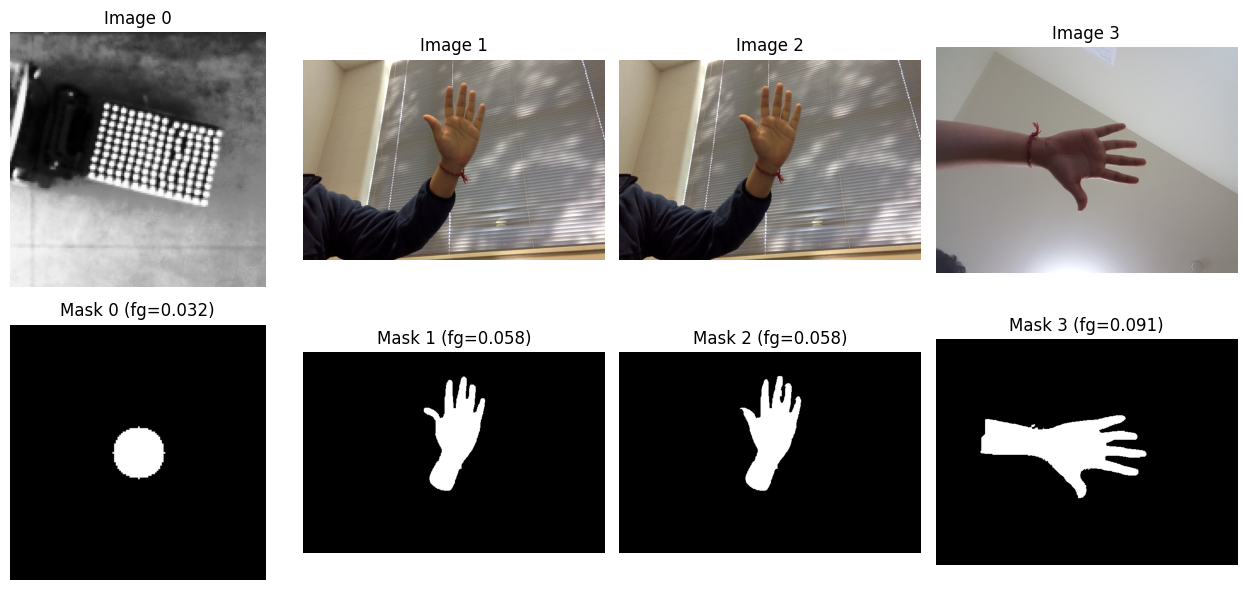

In [3]:
# Visual preview of first samples.
n_preview = min(4, len(all_images))
fig, axes = plt.subplots(2, n_preview, figsize=(3.2 * n_preview, 6))
if n_preview == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i in range(n_preview):
    img = all_images[i]
    msk = all_masks[i]
    if img.ndim == 2:
        axes[0, i].imshow(img, cmap='gray')
    else:
        axes[0, i].imshow(np.clip(img, 0.0, 1.0))
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(msk, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Mask {i} (fg={msk.mean():.3f})')
    axes[1, i].axis('off')

plt.tight_layout()
            


In [4]:
# Run experiment on up to 20 images.
import argparse

RESULTS_DIR = PROJECT_ROOT / 'results' / 'segmentation' / 'grabcut'
n_eval = min(20, len(all_images))
print(f'Running evaluation on {n_eval} images...')

args = argparse.Namespace(
    data_path=str(grabcut_path),
    max_images=n_eval,
    resize=[60, 60],
    max_iters=20,
    tol=1e-3,
    damping=0.5,
    lambda_=2.0,
    seed=0,
    results_dir=str(RESULTS_DIR),
    use_gt_unary=True,
)
summary = run_experiment(args)
summary
            


Running evaluation on 20 images...
[1/20] IoU=0.0000 Acc=0.9678 Runtime=5.57s Iter=9 Converged=True
[2/20] IoU=0.9078 Acc=0.9944 Runtime=11.10s Iter=20 Converged=False
[3/20] IoU=0.9005 Acc=0.9939 Runtime=10.98s Iter=20 Converged=False
[4/20] IoU=0.6957 Acc=0.9622 Runtime=11.63s Iter=20 Converged=False
[5/20] IoU=0.8875 Acc=0.9628 Runtime=10.03s Iter=20 Converged=False
[6/20] IoU=0.9104 Acc=0.9894 Runtime=6.84s Iter=13 Converged=True
[7/20] IoU=0.9201 Acc=0.9808 Runtime=10.80s Iter=20 Converged=False
[8/20] IoU=0.8403 Acc=0.9658 Runtime=11.30s Iter=20 Converged=False
[9/20] IoU=0.6509 Acc=0.9303 Runtime=10.40s Iter=20 Converged=False
[10/20] IoU=0.7554 Acc=0.9403 Runtime=11.55s Iter=20 Converged=False
[11/20] IoU=0.7674 Acc=0.9833 Runtime=11.21s Iter=20 Converged=False
[12/20] IoU=0.7869 Acc=0.9819 Runtime=9.71s Iter=20 Converged=False
[13/20] IoU=0.8245 Acc=0.9825 Runtime=9.49s Iter=20 Converged=False
[14/20] IoU=0.8835 Acc=0.9767 Runtime=8.77s Iter=20 Converged=False
[15/20] IoU=0.73

{'num_images': 20,
 'mean_iou': 0.7739525820216098,
 'std_iou': 0.20069683291140542,
 'mean_accuracy': 0.9738888888888889,
 'std_accuracy': 0.017235881679912714,
 'mean_runtime_sec': 9.242617105298995,
 'mean_iterations': 18.6,
 'convergence_rate': 0.2,
 'config': {'data_path': '/mnt/D/mva_P2/GRM/belief_propagation/data/grabcut',
  'max_images': 20,
  'resize': [60, 60],
  'max_iters': 20,
  'tol': 0.001,
  'damping': 0.5,
  'lambda': 2.0,
  'use_gt_unary': True,
  'seed': 0}}

In [5]:
summary_path = RESULTS_DIR / 'summary.json'
with summary_path.open() as f:
    summary = json.load(f)

print(json.dumps(summary, indent=2))
print('Interpretation:')
print(f"- Mean IoU: {summary['mean_iou']:.3f} (higher is better)")
print(f"- IoU std: {summary['std_iou']:.3f} (lower means more stable across images)")
print(f"- Mean accuracy: {summary['mean_accuracy']:.3f}")
print(f"- Convergence rate: {summary['convergence_rate']:.3f}")
            


{
  "num_images": 20,
  "mean_iou": 0.7739525820216098,
  "std_iou": 0.20069683291140542,
  "mean_accuracy": 0.9738888888888889,
  "std_accuracy": 0.017235881679912714,
  "mean_runtime_sec": 9.242617105298995,
  "mean_iterations": 18.6,
  "convergence_rate": 0.2,
  "config": {
    "data_path": "/mnt/D/mva_P2/GRM/belief_propagation/data/grabcut",
    "max_images": 20,
    "resize": [
      60,
      60
    ],
    "max_iters": 20,
    "tol": 0.001,
    "damping": 0.5,
    "lambda": 2.0,
    "use_gt_unary": true,
    "seed": 0
  }
}
Interpretation:
- Mean IoU: 0.774 (higher is better)
- IoU std: 0.201 (lower means more stable across images)
- Mean accuracy: 0.974
- Convergence rate: 0.200


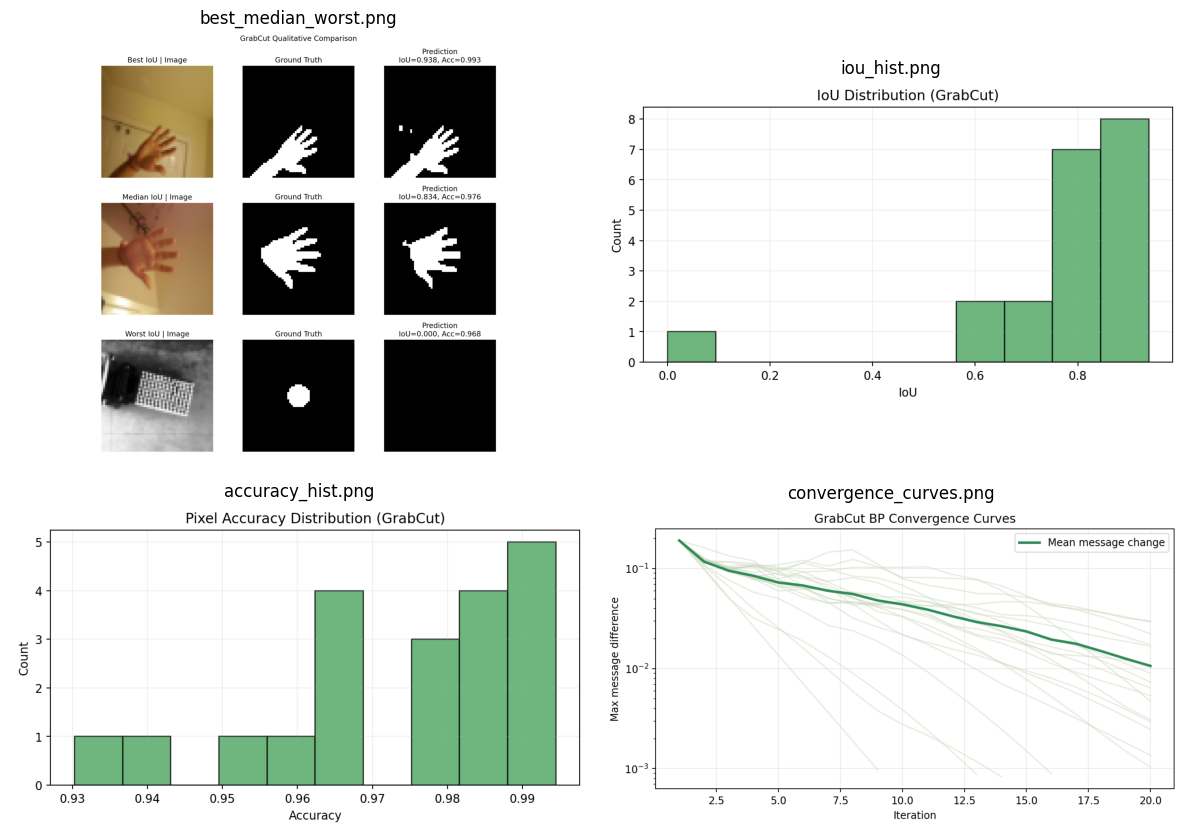

In [6]:
plot_paths = [
    RESULTS_DIR / 'plots' / 'best_median_worst.png',
    RESULTS_DIR / 'plots' / 'iou_hist.png',
    RESULTS_DIR / 'plots' / 'accuracy_hist.png',
    RESULTS_DIR / 'plots' / 'convergence_curves.png',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, path in zip(axes.ravel(), plot_paths):
    if path.exists():
        ax.imshow(plt.imread(path))
        ax.set_title(path.name)
    else:
        ax.text(0.5, 0.5, f'Missing: {path.name}', ha='center', va='center')
    ax.axis('off')
plt.tight_layout()
            
